In [136]:
import pandas as pd
import numpy as np
import umap
import matplotlib.pyplot as plt
from kneed import KneeLocator
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import seaborn as sns
from collections import Counter

In [137]:
pd.set_option('display.max_columns', None)
dfInit = pd.read_csv('student_lifestyle_dataset.csv', delimiter=',', encoding='utf8')
df = dfInit.copy(deep=True)
dfCopy = df.copy(deep=True)
# sesSet = set(df["SES"])
display(df)

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Stress_Level,Gender,Grades
0,1,6.9,3.8,8.7,2.8,1.8,Moderate,Male,7.48
1,2,5.3,3.5,8.0,4.2,3.0,Low,Female,6.88
2,3,5.1,3.9,9.2,1.2,4.6,Low,Male,6.68
3,4,6.5,2.1,7.2,1.7,6.5,Moderate,Male,7.20
4,5,8.1,0.6,6.5,2.2,6.6,High,Male,8.78
...,...,...,...,...,...,...,...,...,...
1995,1996,6.5,0.2,7.4,2.1,7.8,Moderate,Male,8.30
1996,1997,6.3,2.8,8.8,1.5,4.6,Moderate,Female,6.62
1997,1998,6.2,0.0,6.2,0.8,10.8,Moderate,Male,7.85
1998,1999,8.1,0.7,7.6,3.5,4.1,High,Male,7.60


In [138]:
genderDict = { "Male" : 0, "Female" : 1 }
stressDict = {"Low" : 0, "High" : 1, "Moderate" : 2}
df["Gender"] = df["Gender"].map(lambda elem : genderDict[elem])
df["Stress_Level"] = df["Stress_Level"].map(lambda elem : stressDict[elem])
display(df)

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Stress_Level,Gender,Grades
0,1,6.9,3.8,8.7,2.8,1.8,2,0,7.48
1,2,5.3,3.5,8.0,4.2,3.0,0,1,6.88
2,3,5.1,3.9,9.2,1.2,4.6,0,0,6.68
3,4,6.5,2.1,7.2,1.7,6.5,2,0,7.20
4,5,8.1,0.6,6.5,2.2,6.6,1,0,8.78
...,...,...,...,...,...,...,...,...,...
1995,1996,6.5,0.2,7.4,2.1,7.8,2,0,8.30
1996,1997,6.3,2.8,8.8,1.5,4.6,2,1,6.62
1997,1998,6.2,0.0,6.2,0.8,10.8,2,0,7.85
1998,1999,8.1,0.7,7.6,3.5,4.1,1,0,7.60


In [139]:
df = pd.DataFrame(data=StandardScaler().fit_transform(df), columns=df.columns)
display(df)

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Stress_Level,Gender,Grades
0,-1.731185,-0.404487,1.566246,0.820734,0.056543,-1.005896,1.209756,-0.984126,-0.414987
1,-1.729453,-1.528451,1.306633,0.341473,0.885882,-0.528470,-1.771775,1.016130,-1.218641
2,-1.727721,-1.668947,1.652784,1.163063,-0.891273,0.108097,-1.771775,-0.984126,-1.486525
3,-1.725989,-0.685478,0.095105,-0.206253,-0.595080,0.864021,1.209756,-0.984126,-0.790025
4,-1.724257,0.438487,-1.202961,-0.685514,-0.298888,0.903806,-0.281009,-0.984126,1.326263
...,...,...,...,...,...,...,...,...,...
1995,1.724257,-0.685478,-1.549111,-0.069322,-0.358126,1.381232,1.209756,-0.984126,0.683340
1996,1.725989,-0.825974,0.700869,0.889200,-0.713557,0.108097,1.209756,1.016130,-1.566891
1997,1.727721,-0.896221,-1.722187,-0.890911,-1.128226,2.574795,1.209756,-0.984126,0.080600
1998,1.729453,0.438487,-1.116423,0.067610,0.471212,-0.090830,-0.281009,-0.984126,-0.254256


np.int64(5)

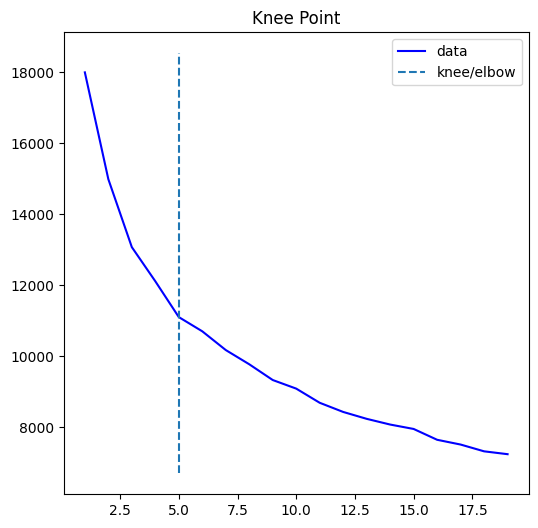

In [140]:
distortions = []
K = range(1, 20)

for k in K:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(df)
    distortions.append(kmeans.inertia_)

kneedle = KneeLocator(K, distortions, curve="convex", direction="decreasing")
n_clusters = kneedle.knee
display(n_clusters)
kneedle.plot_knee()

In [141]:
kmeans = KMeans(n_clusters=5)
kmeans = kmeans.fit_predict(df)

Counter(kmeans)

Counter({np.int32(2): 493,
         np.int32(3): 446,
         np.int32(0): 383,
         np.int32(1): 382,
         np.int32(4): 296})

np.float64(1.1351195515253545)

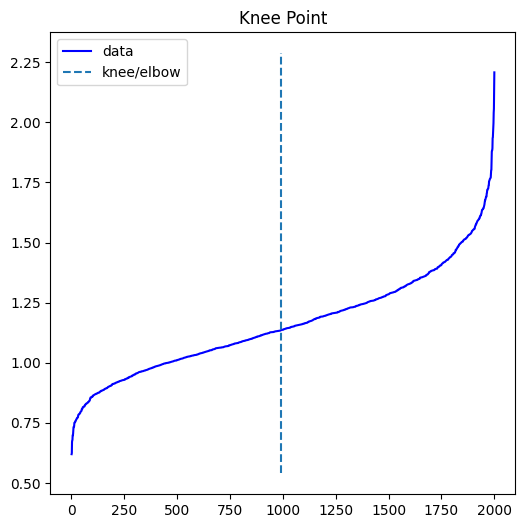

In [142]:
neighbors = NearestNeighbors(n_neighbors=5).fit(df)
neighborsDist, neighborsIndex = neighbors.kneighbors(df)
sortNeighborsDist = np.sort(neighborsDist, axis=0)

x = range(1, len(neighborsDist) + 1)
y = sortNeighborsDist[:, 3]

kneeLocator = KneeLocator(x, y, curve="convex", S=35)
knee = kneeLocator.knee_y
display(knee)
kneeLocator.plot_knee()
plt.show()

In [143]:
clusters = DBSCAN(eps=knee, min_samples=20).fit(df)
Counter(clusters.labels_)

Counter({np.int64(-1): 2000})

<Figure size 3000x2000 with 0 Axes>

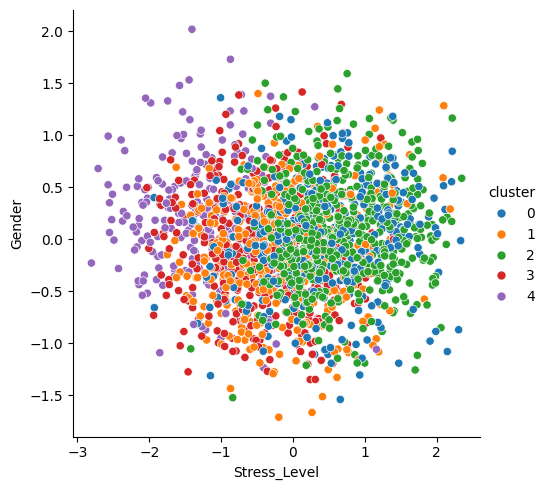

In [144]:
pca = PCA().fit_transform(df)
pca = pd.DataFrame(data=pca, columns=df.columns)

pca["cluster"] = kmeans
pca["cluster"] = pca["cluster"].astype("category")

plt.figure(figsize = (30, 20))
sns.relplot(x="Stress_Level", y="Gender", hue="cluster", data=pca)

<Figure size 3000x2000 with 0 Axes>

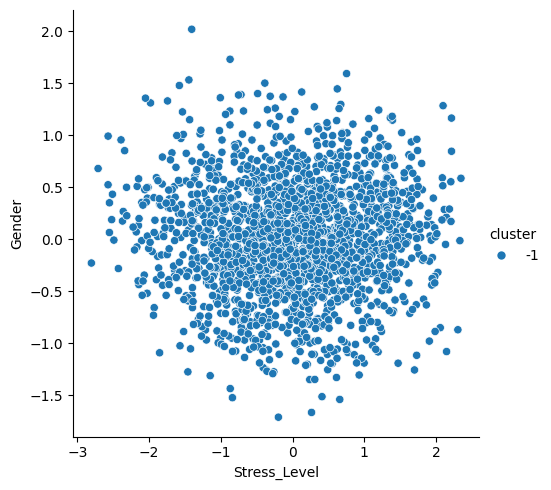

In [145]:
pca["cluster"] = clusters.labels_
pca["cluster"] = pca["cluster"].astype("category")
plt.figure(figsize = (30, 20))

sns.relplot(x="Stress_Level", y="Gender", hue="cluster", data=pca)

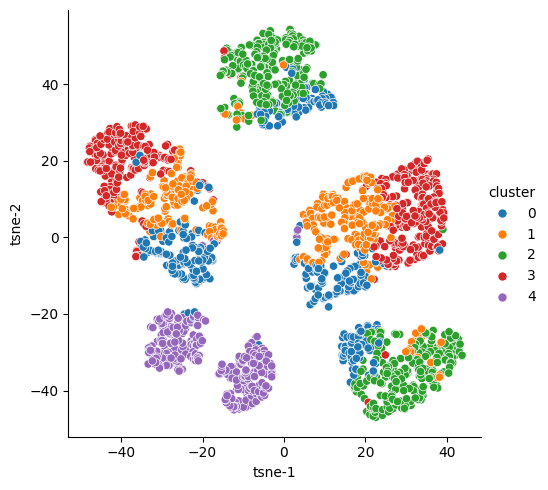

In [146]:
subsetLen = len(df)
subsetDf = df[:subsetLen]

tSNEModel = TSNE().fit_transform(subsetDf)
tSNEDF = pd.DataFrame()

tSNEDF["tsne-1"] = tSNEModel[:, 0]
tSNEDF["tsne-2"] = tSNEModel[:, 1]

tSNEDF["cluster"] = kmeans[: subsetLen]
tSNEDF["cluster"] = tSNEDF["cluster"].astype("category")

sns.relplot(x="tsne-1", y="tsne-2", hue="cluster", data=tSNEDF)

/Users/matvey_agarkov/Desktop/fuzzy_neuro/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


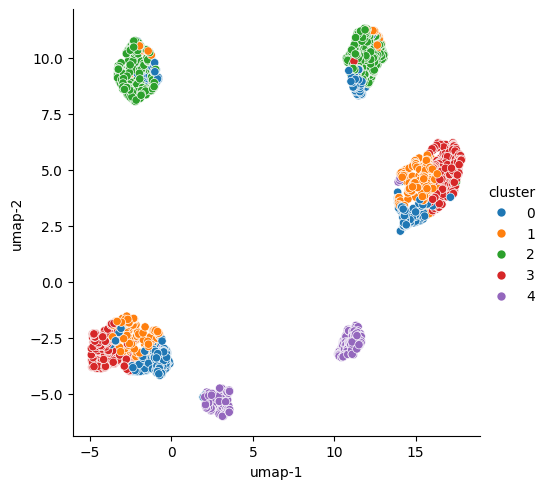

In [147]:
umapModel = umap.UMAP().fit_transform(subsetDf)
umapDF = pd.DataFrame()

umapDF["umap-1"] = umapModel[:, 0]
umapDF["umap-2"] = umapModel[:, 1]

umapDF["cluster"] = kmeans[:subsetLen]
umapDF["cluster"] = umapDF["cluster"].astype("category")

sns.relplot(x="umap-1", y="umap-2", hue="cluster", data=umapDF)

In [ ]:
umapDF["cluster"] = clusters.labels_
umapDF["cluster"] = umapDF["cluster"].astype("category")

sns.relplot(x="umap-1", y="umap-2", hue="cluster", data=umapDF)

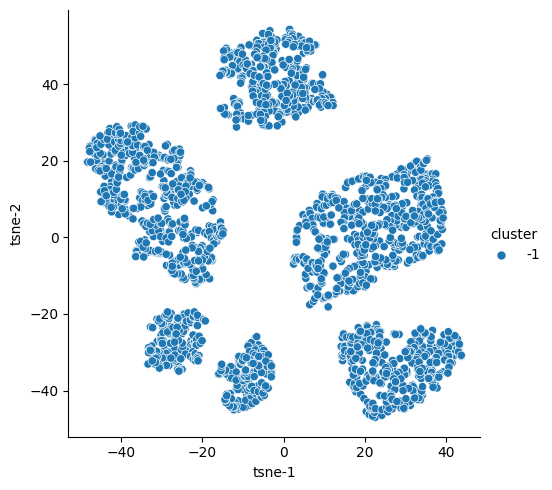

In [148]:
tSNEDF["cluster"] = clusters.labels_
tSNEDF["cluster"] = tSNEDF["cluster"].astype("category")

sns.relplot(x="tsne-1", y="tsne-2", hue="cluster", data=tSNEDF)